## SwiGLU Compression

The purpose of this replacement strategy is to replace original operators with swiGLU operators with variable widths based on selected importance and budget allocation strategies. A simple example given arbitrary importance vector I = [5, 2, 8, 1], blocks should have swiGLU widths assigned w = [w1,w2,w3, w4] respectively so w_i is proportiol to I[i].

The idea of this notebook compression strategy is inspired by ModeGPT budget allocation schema. We take the softmax based global average sparsity allocation/distribution and test different and more complex importance estimation inputs $s_i$

$$
\max_{\boldsymbol{\phi}}
\sum_{i=1}^{L} s_i(1-\phi_i) + \epsilon H(\boldsymbol{\phi})
$$

subject to:

$$
\frac{1}{L}\sum_{i=1}^{L}\phi_i = \phi_{\mathrm{avg}},
\qquad
0 \leq \phi_i \leq 1.
$$


then $\phi_i$ are the individual sparsities allocated for each new MLP operator, this way we can distribute global sparsity across blocks individually.

#### setup

In [1]:
from copy import deepcopy
from dataclasses import asdict
from datetime import datetime, timezone
import json
import math
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

In [2]:
def find_project_root(start):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'mlp_replacement').is_dir():
            return candidate
    raise RuntimeError('Could not locate the repository root')

In [3]:
PROJECT_ROOT = find_project_root(Path.cwd())
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from mlp_replacement.analysis.screening import compute_bi_scores
from mlp_replacement.capture import collect_modules_io
from mlp_replacement.compression.recovery import (
    cache_teacher_logits,
    mean_cache_loss,
    recover_replacements,
)
from mlp_replacement.compression.surgery import temporary_replacements
from mlp_replacement.config import (
    CaptureConfig,
    DataConfig,
    ModelConfig,
    OperatorConfig,
    RecoveryConfig,
)
from mlp_replacement.data import build_data_loaders
from mlp_replacement.evaluation.footprint import parameter_footprint
from mlp_replacement.evaluation.language_model import (
    evaluate_language_model,
)
from mlp_replacement.evaluation.operator import evaluate_operator
from mlp_replacement.model import (
    discover_mlp_blocks,
    load_model_and_tokenizer,
)
from mlp_replacement.operators import (
    GatedMLPReplacement,
    fit_operator,
)

In [4]:
SEED = 21
PROTECTED_PREFIX = 1
PROTECTED_SUFFIX = 1
RECOVERY_BATCHES = 64

In [5]:
torch.manual_seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')

In [6]:
model_config = ModelConfig(
    model_id='HuggingFaceTB/SmolLM2-1.7B',
    device='auto',
    dtype='auto',
)

data_config = DataConfig(
    sequence_length=128,
    batch_size=2,
    num_calibration_batches=48,
    num_operator_validation_batches=24,
    num_recovery_batches=RECOVERY_BATCHES,
    num_recovery_validation_batches=24,
    num_model_validation_batches=24,
    num_test_batches=0,
    seed=SEED,
)

capture_config = CaptureConfig(
    storage_device='cpu',
    storage_dtype='float32',
)

training_config = OperatorConfig(
    kind='swiglu',
    epochs=64,
    learning_rate=1e-3,
    batch_size=2048,
    weight_decay=0.0,
    scheduler='constant',
    early_stopping_patience=3,
    seed=SEED,
)

recovery_config = RecoveryConfig(
    enabled=True,
    epochs=1,
    learning_rate=1e-5,
    weight_decay=0.0,
    temperature=1.0,
    cache_dtype='float16',
    early_stopping_patience=None,
)

#### model and data

In [7]:
model, tokenizer = load_model_and_tokenizer(model_config)
device = next(model.parameters()).device

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

In [8]:
mlp_blocks = discover_mlp_blocks(model)
mlp_blocks_by_layer = {block.index: block for block in mlp_blocks}
available_layers = [block.index for block in mlp_blocks]
eligible_stop = len(available_layers) - PROTECTED_SUFFIX
ELIGIBLE_LAYERS = available_layers[
    PROTECTED_PREFIX:eligible_stop
]
PROTECTED_LAYERS = (
    available_layers[:PROTECTED_PREFIX]
    + available_layers[eligible_stop:]
)

In [9]:
loaders = build_data_loaders(
    tokenizer,
    data_config,
    include_recovery=True,
)

Token indices sequence length is longer than the specified maximum sequence length for this model (268279 > 8192). Running this sequence through the model will result in indexing errors


#### original reference

In [10]:
dense_footprint = parameter_footprint(model)
original_mlp_parameters = {
    layer: sum(
        parameter.numel()
        for parameter in mlp_blocks_by_layer[layer].module.parameters()
    )
    for layer in available_layers
}
eligible_mlp_parameters = sum(
    original_mlp_parameters[layer] for layer in ELIGIBLE_LAYERS
)
fixed_model_parameters = (
    dense_footprint.parameters - eligible_mlp_parameters
)
dense_metrics = evaluate_language_model(
    model,
    loaders.model_validation,
    device,
    data_config.num_model_validation_batches,
)
validation_teacher_cache = cache_teacher_logits(
    model,
    loaders.model_validation,
    data_config.num_model_validation_batches,
    device,
    recovery_config.cache_dtype,
)

original_reference_df = pd.DataFrame([{
    'variant': 'dense_reference',
    'layers': len(available_layers),
    'eligible_layers': len(ELIGIBLE_LAYERS),
    'parameters': dense_footprint.parameters,
    'eligible_mlp_parameters': eligible_mlp_parameters,
    'fixed_model_parameters': fixed_model_parameters,
    'theoretical_weight_bytes': (
        dense_footprint.theoretical_weight_bytes
    ),
    'teacher_kl': 0.0,
    'loss': dense_metrics.loss,
    'perplexity': dense_metrics.perplexity,
    'predicted_tokens': dense_metrics.predicted_tokens,
    'batches': dense_metrics.batches,
}])

display(original_reference_df)

,variant,layers,eligible_layers,parameters,eligible_mlp_parameters,fixed_model_parameters,theoretical_weight_bytes,teacher_kl,loss,perplexity,predicted_tokens,batches
0,dense_reference,24,22,1711376384,1107296256,604080128,3422752768,0.0,2.670184,14.442631,6096,24


#### importance screening (s_i)

1) uniform
2) BI score
3) MLP score (residual-aware)

In [11]:
canonical_bi_result = compute_bi_scores(
    model,
    loaders.calibration,
    data_config.num_calibration_batches,
    device,
    scope='transformer_layer',
    layer_indices=ELIGIBLE_LAYERS,
)
residual_mlp_bi_result = compute_bi_scores(
    model,
    loaders.calibration,
    data_config.num_calibration_batches,
    device,
    scope='mlp_sublayer',
    layer_indices=ELIGIBLE_LAYERS,
)

In [12]:
importance_df = pd.DataFrame({
    'layer': ELIGIBLE_LAYERS,
    'depth_fraction': [
        layer / (len(available_layers) - 1)
        for layer in ELIGIBLE_LAYERS
    ],
    'canonical_bi': [
        canonical_bi_result.scores[layer]
        for layer in ELIGIBLE_LAYERS
    ],
    'residual_aware_mlp_bi': [
        residual_mlp_bi_result.scores[layer]
        for layer in ELIGIBLE_LAYERS
    ],
})

display(importance_df)

,layer,depth_fraction,canonical_bi,residual_aware_mlp_bi
0,1,0.043478,0.265937,0.131768
1,2,0.086957,0.102373,0.082439
2,3,0.130435,0.080143,0.066104
3,4,0.173913,0.064685,0.052066
4,5,0.217391,0.057725,0.044607
5,6,0.260870,0.054293,0.042428
6,7,0.304348,0.069344,0.057179
7,8,0.347826,0.065373,0.054751
8,9,0.391304,0.071133,0.053749
9,10,0.434783,0.065534,0.054281


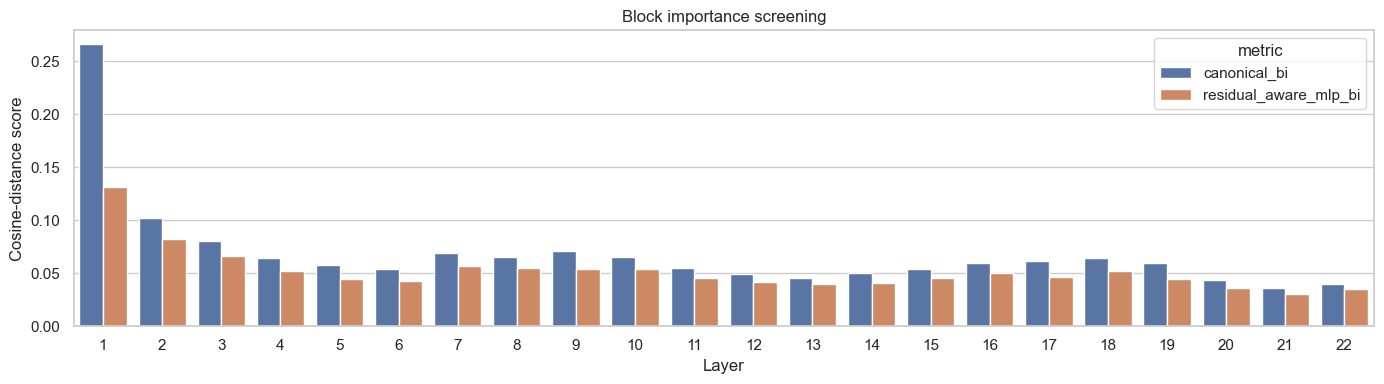

In [13]:
importance_plot_df = importance_df.melt(
    id_vars=['layer'],
    value_vars=['canonical_bi', 'residual_aware_mlp_bi'],
    var_name='metric',
    value_name='score',
)

plt.figure(figsize=(14, 4))
sns.barplot(
    data=importance_plot_df,
    x='layer',
    y='score',
    hue='metric',
)
plt.title('Block importance screening')
plt.xlabel('Layer')
plt.ylabel('Cosine-distance score')
plt.tight_layout()
plt.show()

#### global budget

In [14]:
TARGET_MLP_SPARSITY = 0.50

In [15]:
target_removed_parameters = round(
    eligible_mlp_parameters * TARGET_MLP_SPARSITY
)
target_retained_mlp_parameters = (
    eligible_mlp_parameters - target_removed_parameters
)
target_model_parameters = (
    fixed_model_parameters + target_retained_mlp_parameters
)
target_model_reduction = (
    1 - target_model_parameters / dense_footprint.parameters
)

global_budget_df = pd.DataFrame([{
    'target_scope': 'eligible_mlp',
    'target_reduction': TARGET_MLP_SPARSITY,
    'target_retention': 1 - TARGET_MLP_SPARSITY,
    'original_eligible_mlp_parameters': eligible_mlp_parameters,
    'target_removed_parameters': target_removed_parameters,
    'target_retained_mlp_parameters': (
        target_retained_mlp_parameters
    ),
    'fixed_model_parameters': fixed_model_parameters,
    'target_model_parameters': target_model_parameters,
    'target_model_reduction': target_model_reduction,
}])

display(global_budget_df)

,target_scope,target_reduction,target_retention,original_eligible_mlp_parameters,target_removed_parameters,target_retained_mlp_parameters,fixed_model_parameters,target_model_parameters,target_model_reduction
0,eligible_mlp,0.5,0.5,1107296256,553648128,553648128,604080128,1157728256,0.32351


#### allocation strategies

In [16]:
ALLOCATION_TEMPERATURE = 1.0

allocation_importance = {
    'canonical_bi': canonical_bi_result.scores,
    'residual_aware_mlp_bi': residual_mlp_bi_result.scores,
}

In [17]:
def rank_normalize_scores(scores):
    values = pd.Series(scores, dtype=float)
    return (
        (values.rank(method='average') - 1) / (len(values) - 1)
    ).to_dict()


def allocate_swiglu_widths(policy, scores=None):
    original_parameters = {
        layer: original_mlp_parameters[layer]
        for layer in ELIGIBLE_LAYERS
    }
    normalized_scores = (
        rank_normalize_scores(scores) if scores is not None else None
    )
    removal_propensity = {
        layer: (
            math.exp(
                -normalized_scores[layer] / ALLOCATION_TEMPERATURE
            )
            if normalized_scores is not None
            else 1.0
        )
        for layer in ELIGIBLE_LAYERS
    }
    removal_denominator = sum(
        original_parameters[layer] * removal_propensity[layer]
        for layer in ELIGIBLE_LAYERS
    )

    rows = []
    for layer in ELIGIBLE_LAYERS:
        block = mlp_blocks_by_layer[layer].module
        hidden_size = block.up_proj.in_features
        original_width = block.up_proj.out_features
        parameter_step = 3 * hidden_size
        removal_share = (
            original_parameters[layer] * removal_propensity[layer]
            / removal_denominator
        )
        allocated_removal = target_removed_parameters * removal_share
        allocated_parameter_cap = (
            original_parameters[layer] - allocated_removal
        )
        continuous_width = allocated_parameter_cap / parameter_step
        rows.append({
            'policy': policy,
            'layer': layer,
            'raw_importance': (
                scores[layer] if scores is not None else None
            ),
            'normalized_importance': (
                normalized_scores[layer]
                if normalized_scores is not None
                else None
            ),
            'allocated_sparsity': (
                allocated_removal / original_parameters[layer]
            ),
            'allocated_retention': (
                allocated_parameter_cap / original_parameters[layer]
            ),
            'original_width': original_width,
            'continuous_width': continuous_width,
            'replacement_width': int(continuous_width),
            'parameter_step': parameter_step,
            'original_parameters': original_parameters[layer],
        })

    remaining_budget = target_retained_mlp_parameters - sum(
        row['replacement_width'] * row['parameter_step']
        for row in rows
    )
    rounding_order = sorted(
        rows,
        key=lambda row: (
            row['continuous_width'] - row['replacement_width']
        ),
        reverse=True,
    )
    for row in rounding_order:
        if row['parameter_step'] <= remaining_budget:
            row['replacement_width'] += 1
            remaining_budget -= row['parameter_step']

    for row in rows:
        row['replacement_width_ratio'] = (
            row['replacement_width'] / row['original_width']
        )
        row['replacement_parameters'] = (
            row['replacement_width'] * row['parameter_step']
        )
        row['realized_sparsity'] = (
            1
            - row['replacement_parameters'] / row['original_parameters']
        )

    return pd.DataFrame(rows).drop(
        columns=['continuous_width', 'parameter_step']
    )

In [18]:
allocation_df = pd.concat(
    [
        allocate_swiglu_widths('uniform'),
        allocate_swiglu_widths(
            'canonical_bi', allocation_importance['canonical_bi']
        ),
        allocate_swiglu_widths(
            'residual_aware_mlp_bi',
            allocation_importance['residual_aware_mlp_bi'],
        ),
    ],
    ignore_index=True,
)

allocation_summary_df = (
    allocation_df
    .groupby('policy', sort=False, as_index=False)
    .agg(
        original_mlp_parameters=('original_parameters', 'sum'),
        replacement_mlp_parameters=('replacement_parameters', 'sum'),
        minimum_width_ratio=('replacement_width_ratio', 'min'),
        maximum_width_ratio=('replacement_width_ratio', 'max'),
    )
)
allocation_summary_df['mlp_sparsity'] = (
    1
    - allocation_summary_df['replacement_mlp_parameters']
    / allocation_summary_df['original_mlp_parameters']
)
allocation_summary_df['model_parameters'] = (
    fixed_model_parameters
    + allocation_summary_df['replacement_mlp_parameters']
)
allocation_summary_df['model_sparsity'] = (
    1
    - allocation_summary_df['model_parameters']
    / dense_footprint.parameters
)
allocation_summary_df['retained_budget_difference'] = (
    allocation_summary_df['replacement_mlp_parameters']
    - target_retained_mlp_parameters
)

allocation_width_df = (
    allocation_df
    .pivot(
        index='layer',
        columns='policy',
        values='replacement_width_ratio',
    )
    .reset_index()
)

display(allocation_summary_df)
display(allocation_width_df)

,policy,original_mlp_parameters,replacement_mlp_parameters,minimum_width_ratio,maximum_width_ratio,mlp_sparsity,model_parameters,model_sparsity,retained_budget_difference
0,uniform,1107296256,553648128,0.500000,0.500000,0.5,1157728256,0.32351,0
1,canonical_bi,1107296256,553648128,0.212036,0.710205,0.5,1157728256,0.32351,0
2,residual_aware_mlp_bi,1107296256,553648128,0.212036,0.710205,0.5,1157728256,0.32351,0


policy,layer,canonical_bi,residual_aware_mlp_bi,uniform
0,1,0.710205,0.710205,0.5
1,2,0.696045,0.696045,0.5
2,3,0.681152,0.681152,0.5
3,4,0.595459,0.575684,0.5
4,5,0.486694,0.435425,0.5
5,6,0.435425,0.407959,0.5
6,7,0.649292,0.665649,0.5
7,8,0.614258,0.649292,0.5
8,9,0.665649,0.614258,0.5
9,10,0.632202,0.632202,0.5


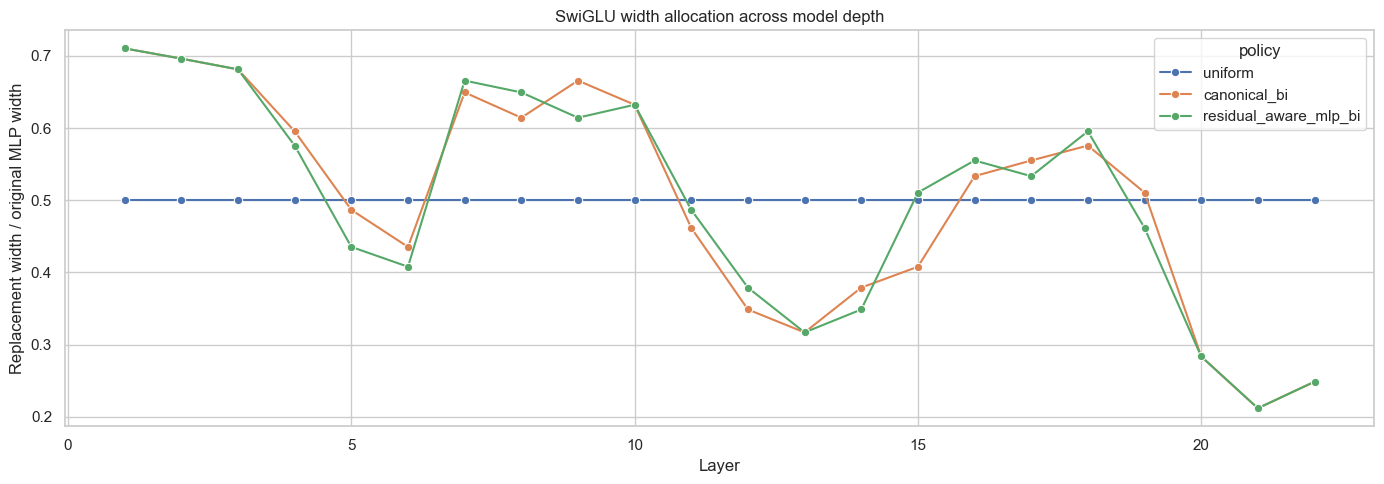

In [19]:
plt.figure(figsize=(14, 5))
sns.lineplot(
    data=allocation_df,
    x='layer',
    y='replacement_width_ratio',
    hue='policy',
    marker='o',
)
plt.title('SwiGLU width allocation across model depth')
plt.xlabel('Layer')
plt.ylabel('Replacement width / original MLP width')
plt.tight_layout()
plt.show()

#### replacement fitting

In [ ]:
eligible_paths = [
    mlp_blocks_by_layer[layer].path for layer in ELIGIBLE_LAYERS
]
training_pairs_by_path = collect_modules_io(
    model,
    eligible_paths,
    loaders.calibration,
    data_config.num_calibration_batches,
    device,
    storage_device=capture_config.storage_device,
    storage_dtype=torch.float32,
)
validation_pairs_by_path = collect_modules_io(
    model,
    eligible_paths,
    loaders.operator_validation,
    data_config.num_operator_validation_batches,
    device,
    storage_device=capture_config.storage_device,
    storage_dtype=torch.float32,
)

In [ ]:
fitted_operators = {}
fitting_rows = []
history_rows = []

for policy, policy_allocation in allocation_df.groupby(
    'policy', sort=False
):
    fitted_operators[policy] = {}
    for allocation in policy_allocation.itertuples(index=False):
        layer = int(allocation.layer)
        block = mlp_blocks_by_layer[layer]
        training_pairs = training_pairs_by_path[block.path]
        validation_pairs = validation_pairs_by_path[block.path]
        module = GatedMLPReplacement(
            training_pairs.hidden_size,
            int(allocation.replacement_width),
        )
        fit = fit_operator(
            module,
            training_pairs,
            validation_pairs,
            training_config,
            device,
        )
        metrics = evaluate_operator(
            fit.module,
            validation_pairs,
            device,
            training_config.batch_size,
        )
        fitted_operators[policy][layer] = fit.module.to('cpu')
        fitting_rows.append({
            'policy': policy,
            'layer': layer,
            'replacement_width': int(allocation.replacement_width),
            'replacement_width_ratio': (
                allocation.replacement_width_ratio
            ),
            'replacement_parameters': (
                allocation.replacement_parameters
            ),
            'best_epoch': fit.best_epoch,
            'local_mse': metrics.mse,
            'local_relative_mse': metrics.relative_mse,
            'local_cosine': metrics.cosine_similarity,
        })
        for epoch in fit.history:
            history_rows.append({
                'policy': policy,
                'layer': layer,
                'epoch': epoch.epoch,
                'train_mse': epoch.train_mse,
                'validation_mse': epoch.validation_mse,
                'learning_rate': epoch.learning_rate,
            })

In [ ]:
operator_fitting_df = pd.DataFrame(fitting_rows)
operator_training_history_df = pd.DataFrame(history_rows)

display(operator_fitting_df)

#### model integration and evaluation

In [ ]:
training_pairs_by_path.clear()
validation_pairs_by_path.clear()
training_pairs = None
validation_pairs = None

recovery_teacher_cache = cache_teacher_logits(
    model,
    loaders.recovery,
    data_config.num_recovery_batches,
    device,
    recovery_config.cache_dtype,
)
recovery_validation_teacher_cache = cache_teacher_logits(
    model,
    loaders.recovery_validation,
    data_config.num_recovery_validation_batches,
    device,
    recovery_config.cache_dtype,
)

In [ ]:
evaluation_rows = []
recovery_rows = []

for policy in allocation_df['policy'].drop_duplicates():
    replacements = {
        layer: deepcopy(fitted_operators[policy][layer])
        for layer in ELIGIBLE_LAYERS
    }
    with temporary_replacements(model, replacements) as manifest:
        target_paths = [record.path for record in manifest.records]
        footprint = parameter_footprint(model)
        pre_metrics = evaluate_language_model(
            model,
            loaders.model_validation,
            device,
            data_config.num_model_validation_batches,
        )
        pre_kl = mean_cache_loss(
            model,
            validation_teacher_cache,
            recovery_config.temperature,
            device,
        )
        evaluation_rows.append({
            'policy': policy,
            'phase': 'pre_recovery',
            'parameters': footprint.parameters,
            'model_sparsity': (
                1 - footprint.parameters / dense_footprint.parameters
            ),
            'theoretical_weight_bytes': (
                footprint.theoretical_weight_bytes
            ),
            'teacher_kl': pre_kl,
            'loss': pre_metrics.loss,
            'loss_delta': pre_metrics.loss - dense_metrics.loss,
            'perplexity': pre_metrics.perplexity,
            'perplexity_delta': (
                pre_metrics.perplexity - dense_metrics.perplexity
            ),
        })

        recovery = recover_replacements(
            model,
            recovery_teacher_cache,
            recovery_validation_teacher_cache,
            target_paths,
            recovery_config,
            device,
        )
        post_metrics = evaluate_language_model(
            model,
            loaders.model_validation,
            device,
            data_config.num_model_validation_batches,
        )
        post_kl = mean_cache_loss(
            model,
            validation_teacher_cache,
            recovery_config.temperature,
            device,
        )
        evaluation_rows.append({
            'policy': policy,
            'phase': 'post_recovery',
            'parameters': footprint.parameters,
            'model_sparsity': (
                1 - footprint.parameters / dense_footprint.parameters
            ),
            'theoretical_weight_bytes': (
                footprint.theoretical_weight_bytes
            ),
            'teacher_kl': post_kl,
            'loss': post_metrics.loss,
            'loss_delta': post_metrics.loss - dense_metrics.loss,
            'perplexity': post_metrics.perplexity,
            'perplexity_delta': (
                post_metrics.perplexity - dense_metrics.perplexity
            ),
        })

        for epoch in recovery.history:
            recovery_rows.append({
                'policy': policy,
                'epoch': epoch.epoch,
                'train_kl': epoch.train_kl,
                'validation_kl': epoch.validation_kl,
                'best_epoch': recovery.best_epoch,
            })

    for replacement in replacements.values():
        replacement.to('cpu')
    del replacements
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [ ]:
model_evaluation_df = pd.DataFrame(evaluation_rows)
recovery_history_df = pd.DataFrame(recovery_rows)

display(model_evaluation_df)
display(recovery_history_df)

#### result comparison

In [ ]:
local_summary_df = (
    operator_fitting_df
    .groupby('policy', sort=False, as_index=False)
    .agg(
        mean_local_relative_mse=('local_relative_mse', 'mean'),
        mean_local_cosine=('local_cosine', 'mean'),
    )
)
pre_recovery_df = (
    model_evaluation_df
    .query("phase == 'pre_recovery'")
    [[
        'policy', 'teacher_kl', 'loss', 'loss_delta',
        'perplexity', 'perplexity_delta',
    ]]
    .rename(columns={
        'teacher_kl': 'pre_recovery_kl',
        'loss': 'pre_recovery_loss',
        'loss_delta': 'pre_recovery_loss_delta',
        'perplexity': 'pre_recovery_perplexity',
        'perplexity_delta': 'pre_recovery_perplexity_delta',
    })
)
post_recovery_df = (
    model_evaluation_df
    .query("phase == 'post_recovery'")
    [[
        'policy', 'teacher_kl', 'loss', 'loss_delta',
        'perplexity', 'perplexity_delta',
    ]]
    .rename(columns={
        'teacher_kl': 'post_recovery_kl',
        'loss': 'post_recovery_loss',
        'loss_delta': 'post_recovery_loss_delta',
        'perplexity': 'post_recovery_perplexity',
        'perplexity_delta': 'post_recovery_perplexity_delta',
    })
)

comparison_df = (
    allocation_summary_df
    .merge(local_summary_df, on='policy', validate='one_to_one')
    .merge(pre_recovery_df, on='policy', validate='one_to_one')
    .merge(post_recovery_df, on='policy', validate='one_to_one')
)
comparison_df['kl_reduction'] = (
    comparison_df['pre_recovery_kl']
    - comparison_df['post_recovery_kl']
)
comparison_df['perplexity_reduction'] = (
    comparison_df['pre_recovery_perplexity']
    - comparison_df['post_recovery_perplexity']
)

display(comparison_df)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=model_evaluation_df,
    x='policy',
    y='teacher_kl',
    hue='phase',
    errorbar=None,
    ax=axes[0],
)
axes[0].set_title('Teacher-to-student KL divergence')
axes[0].set_xlabel('Allocation policy')
axes[0].set_ylabel('KL divergence')
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(
    data=model_evaluation_df,
    x='policy',
    y='perplexity',
    hue='phase',
    errorbar=None,
    ax=axes[1],
)
axes[1].axhline(
    dense_metrics.perplexity,
    color='black',
    linestyle='--',
    label='dense reference',
)
axes[1].set_yscale('log')
axes[1].set_title('Model perplexity')
axes[1].set_xlabel('Allocation policy')
axes[1].set_ylabel('Perplexity (log scale)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()

plt.tight_layout()
plt.show()

#### artifact saving

In [ ]:
def json_records(frame):
    return json.loads(
        frame.to_json(orient='records', double_precision=15)
    )


ARTIFACT_PATH = (
    PROJECT_ROOT
    / 'data'
    / 'results'
    / 'notebook-model-study'
    / 'swiglu-compression.json'
)
artifact = {
    'schema_version': 1,
    'created_at_utc': datetime.now(timezone.utc).isoformat(),
    'configuration': {
        'model': {
            **asdict(model_config),
            'resolved_revision': getattr(
                model.config, '_commit_hash', None
            ),
        },
        'data': asdict(data_config),
        'capture': asdict(capture_config),
        'operator_training': asdict(training_config),
        'recovery': {
            **asdict(recovery_config),
            'trainable_scope': 'replacement_only',
        },
        'target_mlp_sparsity': TARGET_MLP_SPARSITY,
        'allocation_temperature': ALLOCATION_TEMPERATURE,
        'eligible_layers': list(ELIGIBLE_LAYERS),
        'protected_layers': list(PROTECTED_LAYERS),
    },
    'results': {
        'dense_reference': json_records(original_reference_df),
        'importance': json_records(importance_df),
        'global_budget': json_records(global_budget_df),
        'allocation': json_records(allocation_df),
        'allocation_summary': json_records(
            allocation_summary_df
        ),
        'operator_fitting': json_records(operator_fitting_df),
        'operator_training_history': json_records(
            operator_training_history_df
        ),
        'model_evaluation': json_records(model_evaluation_df),
        'recovery_history': json_records(recovery_history_df),
        'comparison': json_records(comparison_df),
    },
}

ARTIFACT_PATH.parent.mkdir(parents=True, exist_ok=True)
ARTIFACT_PATH.write_text(
    json.dumps(artifact, indent=2, allow_nan=False),
    encoding='utf-8',
)
print(f'Saved SwiGLU compression artifact to {ARTIFACT_PATH}')